In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

# population structure just within laser

In [2]:
session_path = '../data/co/co9/co9_12122023'
opto_session = MPOptoClass(session_path, laser_channel=3)

love


# co9, inactivate CFA

In [3]:
omitLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, opto_session.laser['laser_bounds'])
omitLaserBounds = omitBoundInBounds(omitLaserBounds, opto_session.laser['ctrl_bounds'])

In [4]:
(CFA_PCs, RFA_PCs), (CFA_PCObj, RFA_PCObj)  = opto_session.apply_PCA(bounds = omitLaserBounds, binsize=5, smooth_type='two sided', sigma=5, concat=True)
(CFA_l_PCs, RFA_l_PCs), (CFA_l_PCObj, RFA_l_PCObj)  = opto_session.apply_PCA(bounds = opto_session.laser['laser_bounds'], binsize=5, smooth_type='two sided', sigma=5, concat=True)
(CFA_c_PCs, RFA_c_PCs), (CFA_c_PCObj, RFA_c_PCObj)  = opto_session.apply_PCA(bounds = opto_session.laser['ctrl_bounds'], binsize=5, smooth_type='two sided', sigma=5, concat=True)


CFA_climb, RFA_climb = opto_session.smoother(bounds = omitLaserBounds, binsize=5, smooth_type='two sided', sigma=5, concat=True)
CFA_ctrl, RFA_ctrl = opto_session.smoother(bounds = opto_session.laser['ctrl_bounds'], binsize=5, smooth_type='two sided', sigma=5, concat=True)
CFA_laser, RFA_laser = opto_session.smoother(bounds = opto_session.laser['laser_bounds'], binsize=5, smooth_type='two sided', sigma=5, concat=True)

CFA_PCs2 = CFA_l_PCObj.transform(CFA_climb)
RFA_PCs2 = RFA_l_PCObj.transform(RFA_climb)

CFA_PCs3 = CFA_c_PCObj.transform(CFA_climb)
RFA_PCs3 = RFA_c_PCObj.transform(RFA_climb)

#CFA_l_PCs2 = CFA_PCObj.transform(CFA_laser)
#RFA_l_PCs2 = RFA_PCObj.transform(RFA_laser)

#CFA_c_PCs2 = CFA_PCObj.transform(CFA_ctrl)
#RFA_c_PCs2 = RFA_PCObj.transform(RFA_ctrl)

# population structure during stims

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


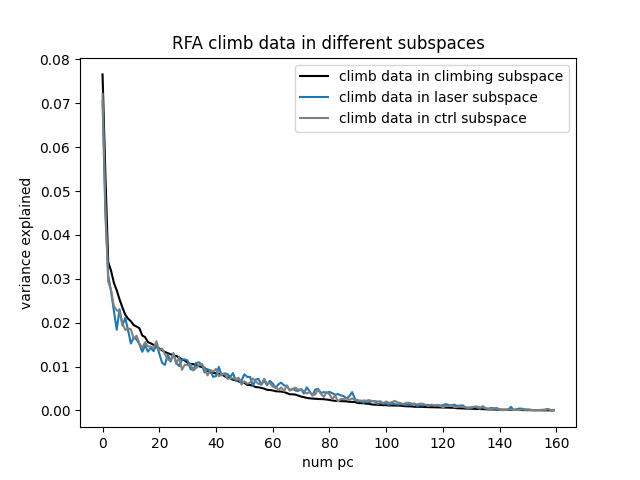

In [5]:
fig0, ax0= plt.subplots()
#ax.plot(varexplained(RFA_PCs), color='black', label='fit subspace')
ax0.plot(varexplained(RFA_PCs), color='black', label='climb data in climbing subspace')
ax0.plot(varexplained(RFA_PCs2), color='tab:blue', label='climb data in laser subspace')
ax0.plot(varexplained(RFA_PCs3), color='gray', label='climb data in ctrl subspace')
ax0.set_xlabel('num pc')
ax0.set_ylabel('variance explained')
ax0.set_title('RFA climb data in different subspaces')

ax0.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


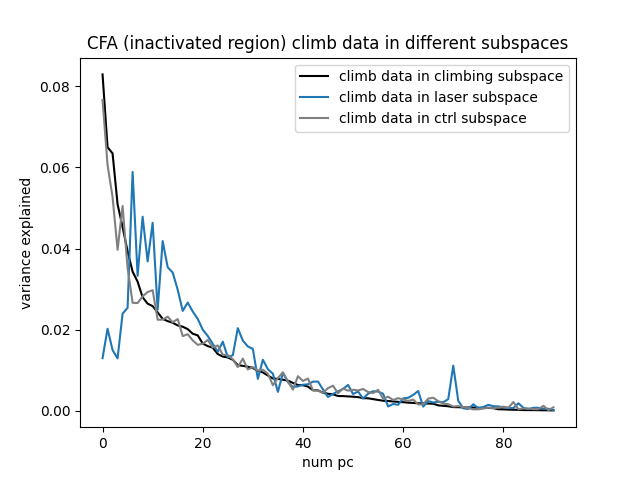

In [6]:
fig00, ax00= plt.subplots()
#ax.plot(varexplained(RFA_PCs), color='black', label='fit subspace')
ax00.plot(varexplained(CFA_PCs), color='black', label='climb data in climbing subspace')
ax00.plot(varexplained(CFA_PCs2), color='tab:blue', label='climb data in laser subspace')
ax00.plot(varexplained(CFA_PCs3), color='gray', label='climb data in ctrl subspace')
ax00.set_xlabel('num pc')
ax00.set_ylabel('variance explained')
ax00.set_title('CFA (inactivated region) climb data in different subspaces')

ax00.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


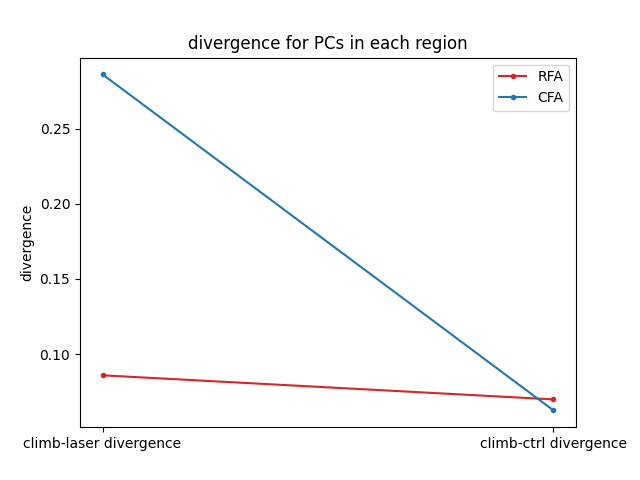

In [7]:
fig01, ax01 = plt.subplots()
rfa_laser_divergence =opto_session.divergence(RFA_PCs, RFA_PCs2)
rfa_ctrl_divergence =opto_session.divergence(RFA_PCs, RFA_PCs3)
cfa_laser_divergence =opto_session.divergence(CFA_PCs, CFA_PCs2)
cfa_ctrl_divergence =opto_session.divergence(CFA_PCs, CFA_PCs3)
ax01.plot(['climb-laser divergence', 'climb-ctrl divergence'], [rfa_laser_divergence,rfa_ctrl_divergence], marker='.', color='tab:red', label='RFA')
ax01.plot(['climb-laser divergence', 'climb-ctrl divergence'], [cfa_laser_divergence,cfa_ctrl_divergence], marker='.', color='tab:blue', label='CFA')
ax01.set_ylabel('divergence')
ax01.set_title('divergence for PCs in each region')
ax01.legend()
#ax01.scatter('RFA climb-laser divergence', laser_divergence, color='tab:blue')
#ax01.scatter('RFA climb-ctrl divergence', ctrl_divergence, color='gray')

# dabbling into new session

In [41]:
session_path = '../data/co/co10/co10_01242024'
opto_session = MPOptoClass(session_path, laser_channel=3)

love


In [33]:
omitLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, opto_session.laser['laser_bounds'])
omitLaserBounds = omitBoundInBounds(omitLaserBounds, opto_session.laser['ctrl_bounds'])

In [34]:
(CFA_PCs, RFA_PCs), (CFA_PCObj, RFA_PCObj)  = opto_session.apply_PCA(bounds = omitLaserBounds, binsize=5, smooth_type='two sided', sigma=5, concat=True)
(CFA_l_PCs, RFA_l_PCs), (CFA_l_PCObj, RFA_l_PCObj)  = opto_session.apply_PCA(bounds = opto_session.laser['laser_bounds'], binsize=5, smooth_type='two sided', sigma=5, concat=True)
(CFA_c_PCs, RFA_c_PCs), (CFA_c_PCObj, RFA_c_PCObj)  = opto_session.apply_PCA(bounds = opto_session.laser['ctrl_bounds'], binsize=5, smooth_type='two sided', sigma=5, concat=True)


CFA_climb, RFA_climb = opto_session.smoother(bounds = omitLaserBounds, binsize=5, smooth_type='two sided', sigma=5, concat=True)
CFA_ctrl, RFA_ctrl = opto_session.smoother(bounds = opto_session.laser['ctrl_bounds'], binsize=5, smooth_type='two sided', sigma=5, concat=True)
CFA_laser, RFA_laser = opto_session.smoother(bounds = opto_session.laser['laser_bounds'], binsize=5, smooth_type='two sided', sigma=5, concat=True)

CFA_PCs2 = CFA_l_PCObj.transform(CFA_climb)
RFA_PCs2 = RFA_l_PCObj.transform(RFA_climb)

CFA_PCs3 = CFA_c_PCObj.transform(CFA_climb)
RFA_PCs3 = RFA_c_PCObj.transform(RFA_climb)

#CFA_l_PCs2 = CFA_PCObj.transform(CFA_laser)
#RFA_l_PCs2 = RFA_PCObj.transform(RFA_laser)

#CFA_c_PCs2 = CFA_PCObj.transform(CFA_ctrl)
#RFA_c_PCs2 = RFA_PCObj.transform(RFA_ctrl)

# population structure during stims

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


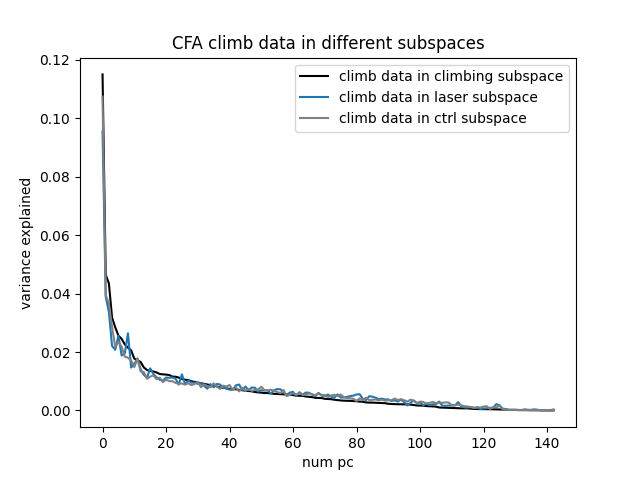

In [35]:
fig1, ax1= plt.subplots()
#ax.plot(varexplained(RFA_PCs), color='black', label='fit subspace')
ax1.plot(varexplained(CFA_PCs), color='black', label='climb data in climbing subspace')
ax1.plot(varexplained(CFA_PCs2), color='tab:blue', label='climb data in laser subspace')
ax1.plot(varexplained(CFA_PCs3), color='gray', label='climb data in ctrl subspace')
ax1.set_xlabel('num pc')
ax1.set_ylabel('variance explained')
ax1.set_title('CFA climb data in different subspaces')

ax1.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


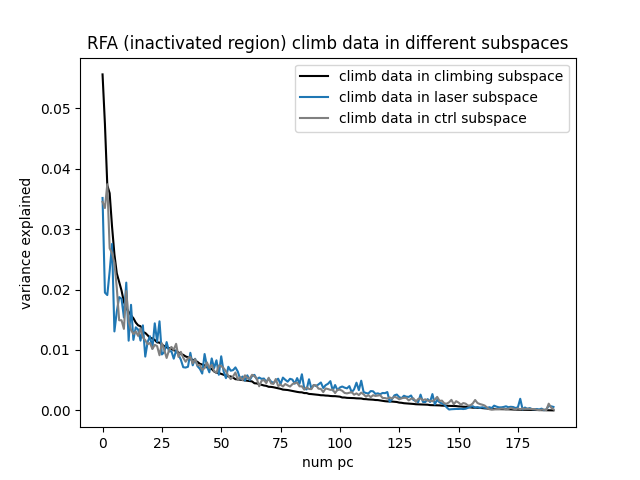

In [36]:
fig11, ax11= plt.subplots()
#ax.plot(varexplained(RFA_PCs), color='black', label='fit subspace')
ax11.plot(varexplained(RFA_PCs), color='black', label='climb data in climbing subspace')
ax11.plot(varexplained(RFA_PCs2), color='tab:blue', label='climb data in laser subspace')
ax11.plot(varexplained(RFA_PCs3), color='gray', label='climb data in ctrl subspace')
ax11.set_xlabel('num pc')
ax11.set_ylabel('variance explained')
ax11.set_title('RFA (inactivated region) climb data in different subspaces')

ax11.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


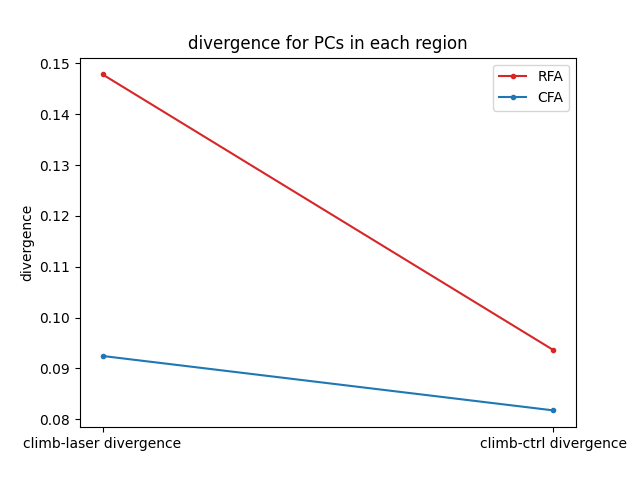

In [37]:
fig01, ax01 = plt.subplots()
rfa_laser_divergence =opto_session.divergence(RFA_PCs, RFA_PCs2)
rfa_ctrl_divergence =opto_session.divergence(RFA_PCs, RFA_PCs3)
cfa_laser_divergence =opto_session.divergence(CFA_PCs, CFA_PCs2)
cfa_ctrl_divergence =opto_session.divergence(CFA_PCs, CFA_PCs3)
ax01.plot(['climb-laser divergence', 'climb-ctrl divergence'], [rfa_laser_divergence,rfa_ctrl_divergence], marker='.', color='tab:red', label='RFA')
ax01.plot(['climb-laser divergence', 'climb-ctrl divergence'], [cfa_laser_divergence,cfa_ctrl_divergence], marker='.', color='tab:blue', label='CFA')
ax01.set_ylabel('divergence')
ax01.set_title('divergence for PCs in each region')
ax01.legend()
#ax01.scatter('RFA climb-laser divergence', laser_divergence, color='tab:blue')
#ax01.scatter('RFA climb-ctrl divergence', ctrl_divergence, color='gray')

In [42]:
num_PCs = 20
laser_bounds, ctrl_bounds = opto_session.adjustLaserBounds(pre=100, post=25)
omitLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, laser_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
omitLaserBounds = minimumBoundSize(bounds = omitLaserBounds, min_size=110)

(X, Y_temp), PCObjs = opto_session.format_nlags_PCA(bounds=omitLaserBounds, num_PCs=num_PCs)
Y = Y_temp[:, :num_PCs]

In [43]:
h = train_wiener_filter(X, Y, c=(2,5))

None
best_c: 21544.346900318822


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


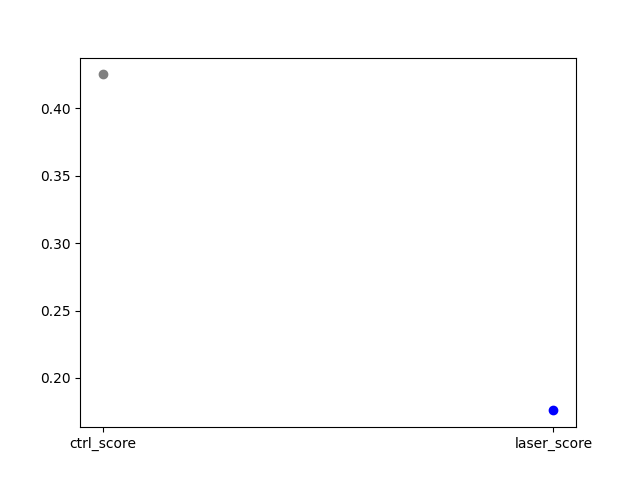

In [44]:
X_ctrl, Y_ctrl_temp = opto_session.transformat(PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs)
Y_ctrl = Y_ctrl_temp[:, :num_PCs:]
X_laser, Y_laser_temp = opto_session.transformat(PCObjs, bounds=laser_bounds, num_PCs=num_PCs)
Y_laser = Y_laser_temp[:, :num_PCs]

ctrl_predic = test_wiener_filter(X_ctrl, h) 
ctrl_score = weighted_r2(Y_ctrl, ctrl_predic)
laser_predic = test_wiener_filter(X_laser, h) 
laser_score = weighted_r2(Y_laser, laser_predic)

fig2, ax2 = plt.subplots()
ax2.scatter('ctrl_score', ctrl_score, color='gray')
ax2.scatter('laser_score', laser_score, color='blue')


In [45]:
opto_session = MPOptoClass(session_path, laser_channel=3)
num_PCs = 20
binsize=5
#nlags=10
sigma=5

nlags_list = np.arange(2,22,2)

ctrl_list = []
test_list = []

for nlags in nlags_list:

    pre=nlags*binsize

    #(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=0)
    #all_cut_CFAPCA = all_cut_PCA[:, :session.num_CFA]

    laser_bounds, ctrl_bounds = opto_session.adjustLaserBounds(pre=pre, post=25)
    #train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8, random_state=1)

    omitLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, laser_bounds)
    omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
    omitLaserBounds = minimumBoundSize(omitLaserBounds, min_size=125)

    (climb_nlags_PCA, nada), climb_PCObjs = opto_session.format_nlags_PCA(bounds=omitLaserBounds, binsize=binsize, nlags=nlags,
                                                                          num_PCs=num_PCs)

    (nada, climb_cut_PCA), nada = opto_session.format_nlags_PCA_smooth(bounds=omitLaserBounds, binsize=binsize, nlags=nlags,smooth_type='future', sigma=sigma,
                                                                       num_PCs=num_PCs)
    climb_CFA_PCA = climb_cut_PCA[:, :num_PCs]


    climb_h = train_wiener_filter(climb_nlags_PCA, climb_CFA_PCA, c=(2,5), sweep='log') 

    climbtest_nlags_PCA, nada = opto_session.transformat(climb_PCObjs, bounds=laser_bounds, num_PCs=num_PCs, binsize=binsize, nlags=nlags)
    nada, climbtest_cut_PCA = opto_session.transformat_smooth(climb_PCObjs, bounds=laser_bounds, num_PCs=num_PCs, binsize=binsize, nlags=nlags, sigma=sigma, smooth_type='future')

    climbtest_CFA_PCA = climbtest_cut_PCA[:, :num_PCs]
    print(climbtest_RFA_PCA.shape)

    climbctrl_nlags_PCA, nada = opto_session.transformat(climb_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, binsize=binsize, nlags=nlags)
    nada, climbctrl_cut_PCA = opto_session.transformat_smooth(climb_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, binsize=binsize, nlags=nlags, sigma=sigma, smooth_type='future')
    climbctrl_CFA_PCA = climbctrl_cut_PCA[:, :num_PCs]

    climbtest_predic_y = test_wiener_filter(climbtest_nlags_PCA, climb_h)
    climbctrl_predic_y = test_wiener_filter(climbctrl_nlags_PCA, climb_h)
    climb_ctrl_score = weighted_r2(climbctrl_CFA_PCA, climbctrl_predic_y)
    climb_test_score = weighted_r2(climbtest_CFA_PCA, climbtest_predic_y)
    
    ctrl_list.append(climb_ctrl_score)
    test_list.append(climb_test_score)

    print(climb_ctrl_score, climb_test_score)



love
None
best_c: 2154.4346900318824


NameError: name 'climbtest_RFA_PCA' is not defined

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'num lags')

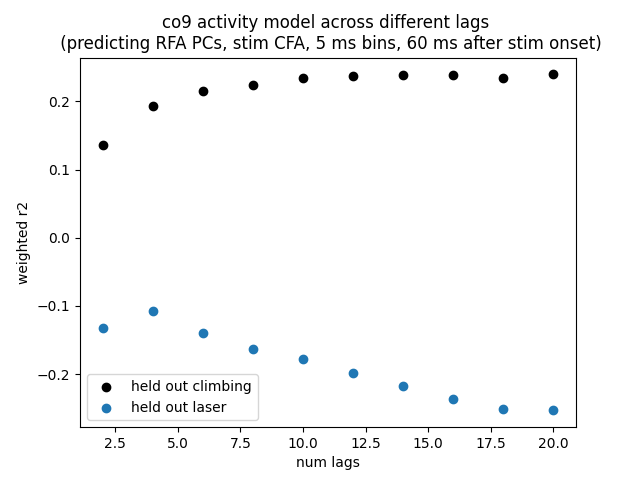

In [141]:
fig, ax = plt.subplots()
x = nlags_list
ax.scatter(x, ctrl_list, label='held out climbing', color='black')
ax.scatter(x, test_list, label = 'held out laser', color='tab:blue')
ax.set_title('co9 activity model across different lags \n (predicting RFA PCs, stim CFA, 5 ms bins, 60 ms after stim onset)')
ax.set_ylabel('weighted r2')
ax.legend()
ax.set_xlabel('num lags')

# chaos dont get past here

In [114]:
train_wiener_filter(

SyntaxError: unexpected EOF while parsing (4125315249.py, line 1)

In [ ]:
fig, ax = plt.subplots()

In [ ]:
CFA_laser, RFA_laser = 

In [44]:
CFA_PCs.shape

(524633, 91)

In [45]:
RFA_PCs.shape

(524633, 160)

In [3]:
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepBinParamsco9_10sw_post60.pickle')

In [4]:
climb_h_wpl = []
laser_h_wpl = []
climb_r2s = []
climbtest_r2s = []
laser_r2s = []
lasertest_r2s = []
nlags = []
for o in output:
    if o == 0:
        continue
    climb_h_wpl.append(opto_session.weights_per_lag(h=o[0], nlags=o[4]))
    laser_h_wpl.append(opto_session.weights_per_lag(h=o[1], nlags=o[4]))
    temp = o[2]
    climb_r2s.append(temp[0])
    climbtest_r2s.append(temp[1])
    temp = o[3]
    laser_r2s.append(temp[0])
    lasertest_r2s.append(temp[1])
    nlags.append(o[4])

    

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


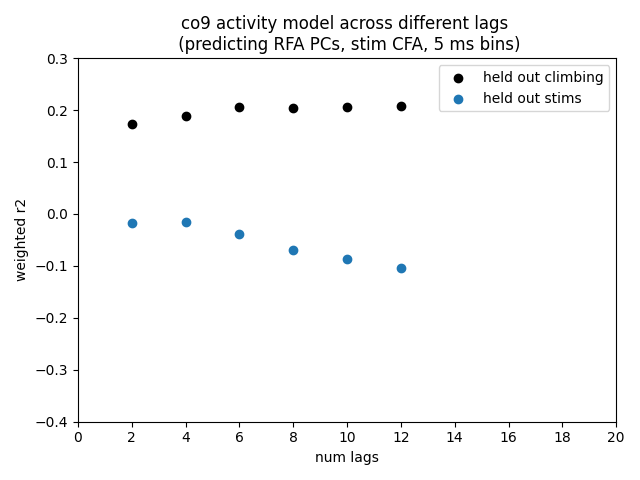

In [6]:
fig0, ax0 = plt.subplots()
ax0.scatter(nlags, climb_r2s, color='black', label='held out climbing')
ax0.scatter(nlags, climbtest_r2s, color='tab:blue', label='held out stims')
ax0.legend()
#ax0.scatter(nlags, laser_r2s, color='gray')
#ax0.scatter(nlags, lasertest_r2s, color='tab:green')
ax0.set_xticks(np.arange(0, 22, 2))
ax0.set_title('co9 activity model across different lags \n (predicting RFA PCs, stim CFA, 5 ms bins)')
ax0.set_ylabel('weighted r2')
ax0.set_xlabel('num lags')
ax0.set_ylim([-.4, .3])
fig0.tight_layout()

# including stims in training

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


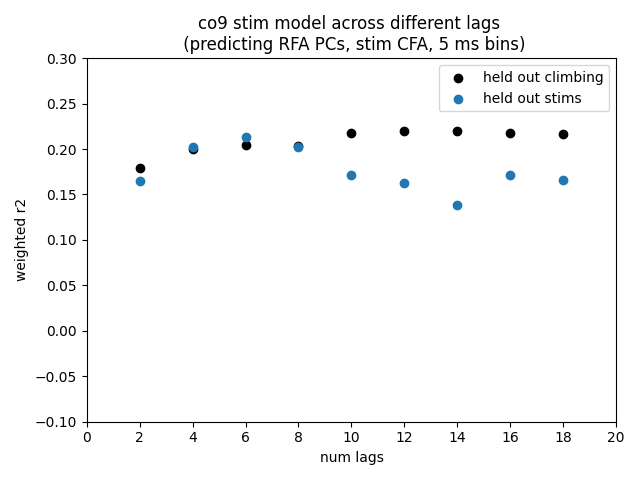

In [7]:
fig01, ax01 = plt.subplots()
#ax01.scatter(nlags, climb_r2s, color='black',  alpha=.2)
#ax01.scatter(nlags, climbtest_r2s, color='tab:blue',  alpha=.2)
ax01.scatter(nlags, laser_r2s, label='held out climbing', color='black')
ax01.scatter(nlags, lasertest_r2s, label='held out stims', color='tab:blue')
ax01.set_xticks(np.arange(0, 22, 2))
ax01.set_ylim([-.1, .3])
ax01.legend()
ax01.set_title('co9 stim model across different lags \n (predicting RFA PCs, stim CFA, 5 ms bins)')
ax01.set_ylabel('weighted r2')
ax01.set_xlabel('num lags')
fig01.tight_layout()

In [8]:
session_path = '../data/co/co9/co9_12122023'
opto_session = MPOptoClass(session_path, post=60, laser_channel=3)
num_PCs = 20
binsize=5
#nlags=10
sigma=5

nlags_list = np.arange(2,22,2)

ctrl_list = []
test_list = []

for nlags in nlags_list:

    pre=nlags*binsize

    #(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=0)
    #all_cut_CFAPCA = all_cut_PCA[:, :session.num_CFA]

    laser_bounds = copy.deepcopy(opto_session.laser['laser_bounds'])
    laser_bounds[:,0] = laser_bounds[:,0] - pre
    ctrl_bounds = copy.deepcopy(opto_session.laser['ctrl_bounds'])
    ctrl_bounds[:,0] = ctrl_bounds[:,0] - pre
    train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8, random_state=1)

    omitLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, laser_bounds)
    omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
    omitLaserBounds = minimumBoundSize(omitLaserBounds, min_size=200)

    (climb_nlags_PCA, nada), climb_PCObjs = opto_session.format_nlags_PCA(bounds=omitLaserBounds, binsize=binsize, nlags=nlags,
                                                                          num_PCs=num_PCs)

    (nada, climb_cut_PCA), nada = opto_session.format_nlags_PCA_smooth(bounds=omitLaserBounds, binsize=binsize, nlags=nlags,smooth_type='future', sigma=sigma,
                                                                       num_PCs=num_PCs)
    climb_RFA_PCA = climb_cut_PCA[:, num_PCs:]


    climb_true_y, climb_predic_y, climb_h = wiener_kfolds(climb_nlags_PCA, climb_RFA_PCA, c=(2,5), sweep='log') 

    climbtest_nlags_PCA, nada = opto_session.transformat(climb_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=binsize, nlags=nlags)
    nada, climbtest_cut_PCA = opto_session.transformat_smooth(climb_PCObjs, bounds=test_lasers, num_PCs=num_PCs, binsize=binsize, nlags=nlags, sigma=sigma, smooth_type='future')

    climbtest_RFA_PCA = climbtest_cut_PCA[:, num_PCs:]
    print(climbtest_RFA_PCA.shape)

    climbctrl_nlags_PCA, nada = opto_session.transformat(climb_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, binsize=binsize, nlags=nlags)
    nada, climbctrl_cut_PCA = opto_session.transformat_smooth(climb_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, binsize=binsize, nlags=nlags, sigma=sigma, smooth_type='future')
    climbctrl_RFA_PCA = climbctrl_cut_PCA[:, num_PCs:]

    climbtest_predic_y = test_wiener_filter(climbtest_nlags_PCA, climb_h)
    climbctrl_predic_y = test_wiener_filter(climbctrl_nlags_PCA, climb_h)
    climb_ctrl_score = weighted_r2(climbctrl_RFA_PCA, climbctrl_predic_y)
    climb_test_score = weighted_r2(climbtest_RFA_PCA, climbtest_predic_y)
    
    ctrl_list.append(climb_ctrl_score)
    test_list.append(climb_test_score)

    print(climb_ctrl_score, climb_test_score)



love


0it [00:00, ?it/s]

None


1it [00:00,  1.50it/s]

best_c: 2154.4346900318824
None


...

None
best_c: 10000.0


3it [00:33, 11.31s/it]

None
best_c: 10000.0


4it [00:46, 11.61s/it]


(264, 20)
0.23167168025125776 -0.3070926228971867


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'num lags')

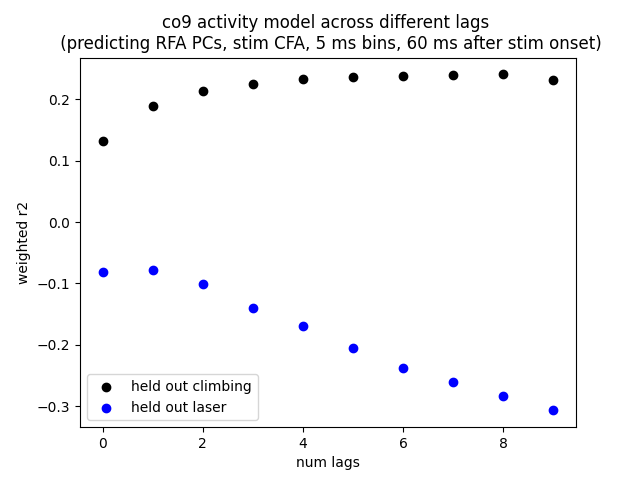

In [9]:
fig, ax = plt.subplots()
x = np.arange(len(ctrl_list))
ax.scatter(x, ctrl_list, label='held out climbing', color='black')
ax.scatter(x, test_list, label = 'held out laser', color='blue')
ax.set_title('co9 activity model across different lags \n (predicting RFA PCs, stim CFA, 5 ms bins, 60 ms after stim onset)')
ax.set_ylabel('weighted r2')
ax.legend()
ax.set_xlabel('num lags')

In [11]:
omitTestLaserBounds = omitBoundInBounds(opto_session.climbing_bounds, test_lasers)
omitTestLaserBounds = omitBoundInBounds(omitTestLaserBounds, ctrl_bounds)
omitTestLaserBounds = minimumBoundSize(omitTestLaserBounds)

sw = opto_session.getSWs(omitTestLaserBounds, train_lasers, sw_weight=25, binsize=5, nlags=4)
#omitAllLaserBounds = omitBoundInBounds(omitTestLaserBounds, train_lasers)

(laser_nlags_PCA, nada), laser_PCObjs = opto_session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, binsize=5, nlags=4, 
                                                                                      smooth_type = 'causal', sigma=5, num_PCs=num_PCs)

(nada, laser_cut_PCA), nada = opto_session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, binsize=5, nlags=4,smooth_type='future', sigma=5,
                                                                   num_PCs=num_PCs)
laser_RFA_PCA = laser_cut_PCA[:, num_PCs:]
lasertest_nlags_PCA, lasertest_cut_PCA = opto_session.transformat_smooth(laser_PCObjs, bounds=test_lasers, num_PCs=num_PCs, sigma=5, smooth_type='causal', binsize=5, nlags=4)
lasertest_RFA_PCA = lasertest_cut_PCA[:, num_PCs:]

laserctrl_nlags_PCA, laserctrl_cut_PCA = opto_session.transformat_smooth(laser_PCObjs, bounds=ctrl_bounds, num_PCs=num_PCs, sigma=5, smooth_type='causal', binsize=5, nlags=4)
laserctrl_RFA_PCA = laserctrl_cut_PCA[:, num_PCs:]


laser_true_y, laser_predic_y, laser_h = wiener_kfolds(laser_nlags_PCA, laser_RFA_PCA, c=(2,5), n_l2=4, sw=sw, sweep='log')


lasertest_predic_y = test_wiener_filter(lasertest_nlags_PCA, laser_h)
laserctrl_predic_y = test_wiener_filter(laserctrl_nlags_PCA, laser_h)



laser_test_score = weighted_r2(lasertest_RFA_PCA, lasertest_predic_y)
laser_ctrl_score = weighted_r2(laserctrl_RFA_PCA, laserctrl_predic_y)

print(laser_ctrl_score, laser_test_score)

0it [00:00, ?it/s]

[1. 1. 1. ... 1. 1. 1.]
best_c: 1000.0


1it [00:02,  2.29s/it]

[1. 1. 1. ... 1. 1. 1.]
best_c: 1000.0


2it [00:04,  2.28s/it]

[1. 1. 1. ... 1. 1. 1.]
best_c: 1000.0


3it [00:06,  2.28s/it]

[1. 1. 1. ... 1. 1. 1.]
best_c: 1000.0


4it [00:09,  2.29s/it]

0.17477829081792504 0.1562922364560629


In [ ]:
fig, ax = plt.subplots()
ax.plot(temp)
ax.plot(sw, color='red')

In [ ]:


print(weighted_r2(climb_true_y, climb_predic_y))
print(weighted_r2(laser_true_y, laser_predic_y))

In [ ]:
fig, ax = plt.subplots()
ax.plot(laser_true_y[:,0], color='black')
ax.plot(laser_predic_y[:,0], color='red')
